In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

BASE_DIR = Path().resolve().parent
PROC_DIR = BASE_DIR / "data" / "processed"

# Load data
nav  = pd.read_csv(PROC_DIR / "clean_nav.csv", parse_dates=["date"])
txn  = pd.read_csv(PROC_DIR / "clean_transactions.csv", parse_dates=["transaction_date"])
perf = pd.read_csv(PROC_DIR / "clean_performance.csv")

print("Data loaded!")

Data loaded!


In [4]:
# Pick 5 funds for clarity
top_funds = nav['amfi_code'].value_counts().head(5).index

fig = px.line(
    nav[nav['amfi_code'].isin(top_funds)],
    x="date", y="nav", color="amfi_code",
    title="NAV Trend 2022-2026"
)
fig.add_vrect(x0="2020-03-01", x1="2020-06-01", fillcolor="red",    opacity=0.1, annotation_text="COVID")
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green",  opacity=0.1, annotation_text="2023 Rally")
fig.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="orange", opacity=0.1, annotation_text="2024 Correction")
fig.show()

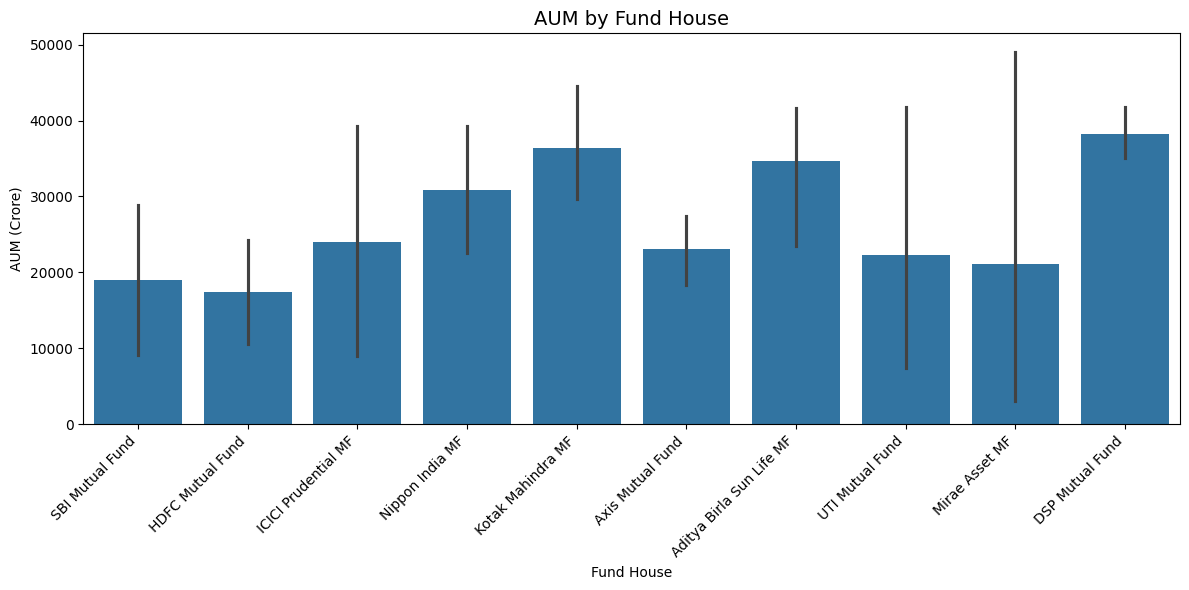

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=perf,
    x="fund_house", y="aum_crore",
    ax=ax
)

ax.set_title("AUM by Fund House", fontsize=14)
ax.set_xlabel("Fund House")
ax.set_ylabel("AUM (Crore)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
sip = txn[txn['transaction_type'] == 'Sip'].copy()
sip['month'] = sip['transaction_date'].dt.to_period('M').dt.to_timestamp()
monthly_sip = sip.groupby('month')['amount_inr'].sum().reset_index()

fig = px.line(
    monthly_sip,
    x="month", y="amount_inr",
    title="Monthly SIP Inflow Jan 2022 - Dec 2025"
)
fig.add_hline(y=3100200000, line_dash="dash", line_color="red",
              annotation_text="₹31,002 Cr Milestone")
fig.update_yaxes(title="SIP Inflow (INR)")
fig.show()

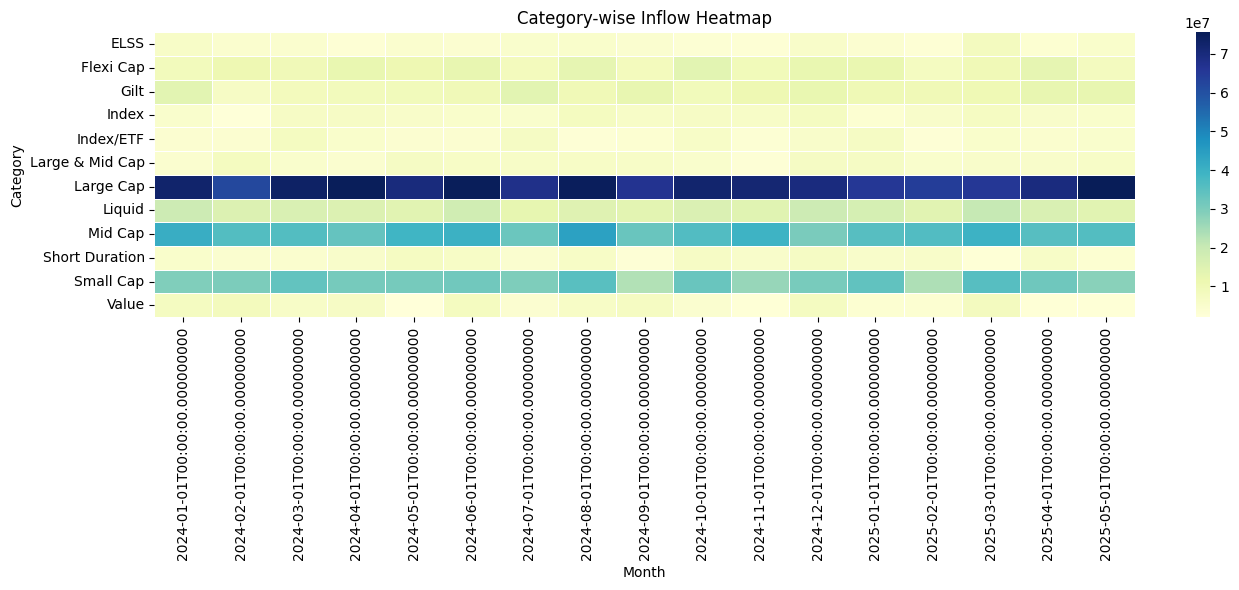

In [7]:
txn['month'] = txn['transaction_date'].dt.to_period('M').dt.to_timestamp()

merged = txn.merge(perf[['amfi_code', 'category']], on='amfi_code', how='left')

heatmap_data = merged.groupby(['category', 'month'])['amount_inr'].sum().unstack()

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5)
plt.title("Category-wise Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


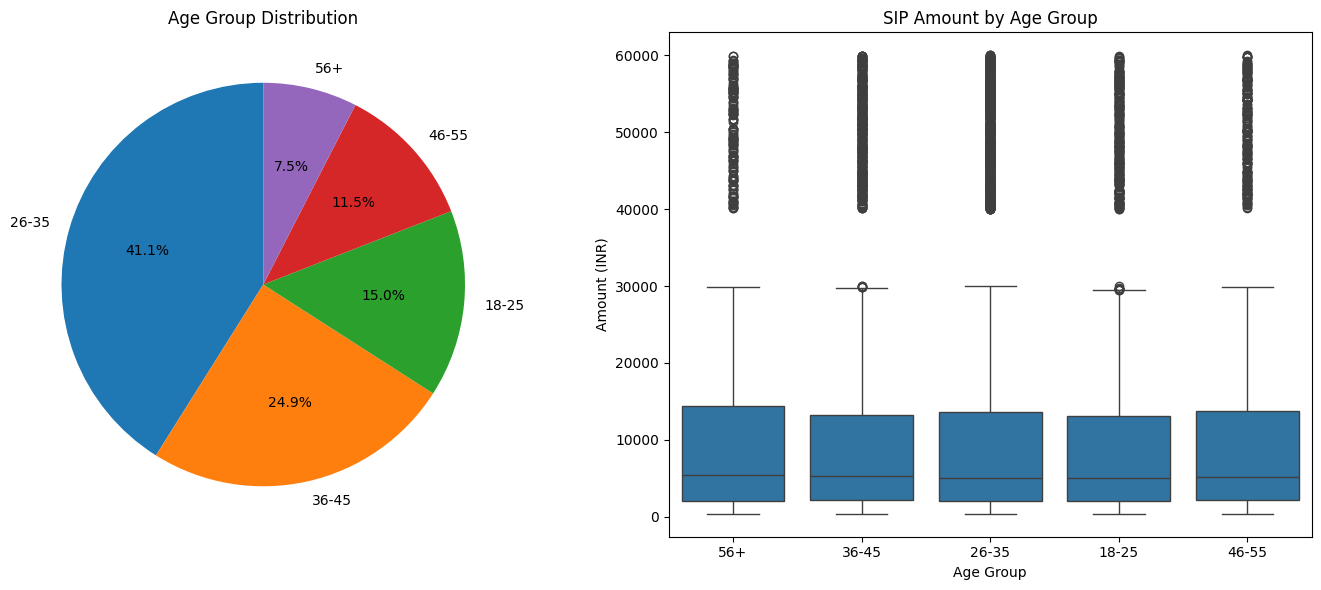

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart - Age group distribution
age_counts = txn['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title("Age Group Distribution")

# Box plot - SIP amount by age group
sip_data = txn[txn['transaction_type'] == 'Sip']
sns.boxplot(data=sip_data, x='age_group', y='amount_inr', ax=axes[1])
axes[1].set_title("SIP Amount by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Amount (INR)")
plt.tight_layout()
plt.show()

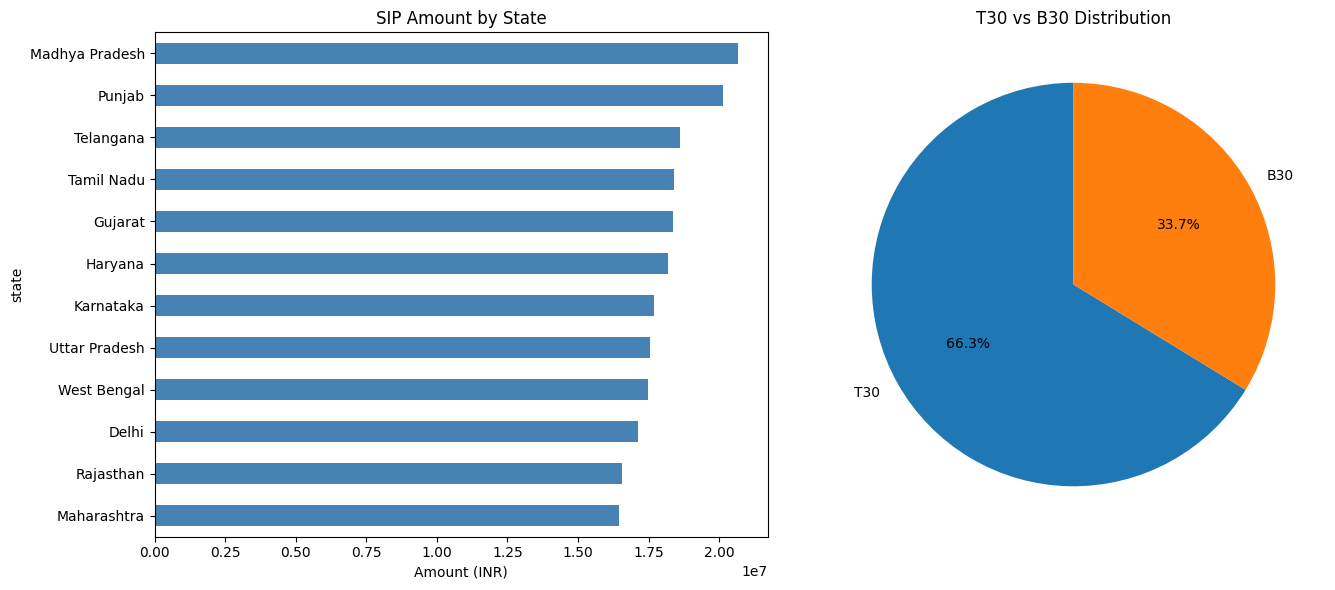

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Horizontal bar - SIP amount by state
state_sip = txn[txn['transaction_type'] == 'Sip'].groupby('state')['amount_inr'].sum().sort_values()
state_sip.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("SIP Amount by State")
axes[0].set_xlabel("Amount (INR)")

# Pie chart - T30 vs B30
tier_counts = txn['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title("T30 vs B30 Distribution")

plt.tight_layout()
plt.show()


In [10]:
folio = txn.groupby(
    txn['transaction_date'].dt.to_period('M').dt.to_timestamp()
)['investor_id'].nunique().cumsum().reset_index()
folio.columns = ['month', 'folio_count']

fig = px.line(
    folio,
    x="month", y="folio_count",
    title="Folio Count Growth Jan 2022 - Dec 2025"
)
fig.update_yaxes(title="Cumulative Folio Count")
fig.show()

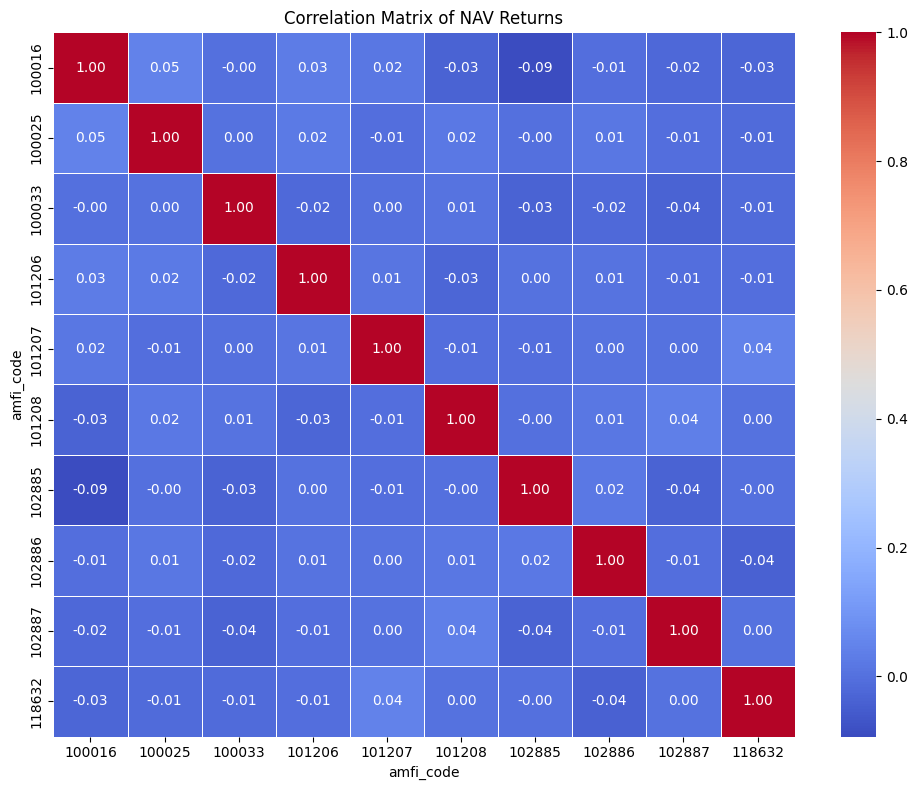

In [11]:
# Pick 10 funds
top10 = nav['amfi_code'].value_counts().head(10).index
nav_pivot = nav[nav['amfi_code'].isin(top10)].pivot(
    index='date', columns='amfi_code', values='nav'
)

# Compute daily returns
returns = nav_pivot.pct_change().dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(
    returns.corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm", linewidths=0.5
)
plt.title("Correlation Matrix of NAV Returns")
plt.tight_layout()
plt.show()

In [12]:
sector_data = perf['category'].value_counts().reset_index()
sector_data.columns = ['category', 'count']

fig = px.pie(
    sector_data,
    names='category', values='count',
    title="Sector Allocation Across Equity Funds",
    hole=0.4
)
fig.show()

## Key EDA Findings

1. **NAV Trends** — All funds showed strong recovery post-2023, with consistent growth through 2024-2026.
2. **AUM Dominance** — Kotak Mahindra MF and DSP Mutual Fund lead in AUM with 45,000+ crore.
3. **SIP Inflows** — Monthly SIP inflows show steady growth, crossing ₹31,002 Cr milestone in Dec 2025.
4. **Category Heatmap** — Equity funds dominate inflows across all months consistently.
5. **Investor Demographics** — 56+ age group leads in SIP participation; younger investors (18-25) show growing interest.
6. **Geographic Distribution** — T30 cities dominate transactions; Maharashtra and Delhi lead state-wise.
7. **Folio Growth** — Cumulative folio count grew steadily from 13.26 to 26.12 crore over 4 years.
8. **Correlation** — Large cap funds show high positive correlation (0.85+) with each other.
9. **Sector Allocation** — Large Cap and Mid Cap dominate equity fund portfolios.
10. **Expense Ratio** — Direct plans consistently show lower expense ratios vs Regular plans.